# Figure S6 — PANCAN ROC curves per cancer type

The full PANCAN model (Figure 5a) evaluated per individual cancer type: each
panel restricts the outer-fold test sets to healthy controls plus one cancer
type and shows the mean ROC (± 1 SD over folds) for the data-driven model
and the RNA, ATAC and ichorCNA baselines.

**Source data**: `data/fig5a_predictions.csv` + `data/fig5a_config.csv` — the
same per-sample out-of-fold predictions as Figure 5a (written by
`export/export_fig5.py`; the exporter asserts that per-cancer-type AUCs
recomputed this way equal the values stored by the pipeline). No pickles, no
cluster paths, no network. Run top to bottom from `src/figures/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from sklearn.metrics import roc_curve, auc

APPROACH_COLORS = {
    "RNA": "#CA3542", "ATAC": "#ECB22E",
    "Data-driven": "#0173B2", "ichorCNA": "#6A3D9A",
}
METHOD_LABELS = {"data_driven": "Data-driven", "rna": "RNA", "atac": "ATAC",
                 "ichorcna": "ichorCNA"}

pred = pd.read_csv("data/fig5a_predictions.csv")
in_task = pred[pred["fold"].notna()]

sample_disease = (in_task[in_task["method"] == "data_driven"]
                  .drop_duplicates("sample_id").set_index("sample_id")["disease"])
cancer_types = sorted(sample_disease[sample_disease != "Healthy"].unique())
n_healthy = int((sample_disease == "Healthy").sum())
counts = sample_disease.value_counts()
print(f"{len(cancer_types)} cancer types; healthy n={n_healthy}")
print(counts.to_string())

7 cancer types; healthy n=210
disease
Healthy                    210
Breast cancer               54
Pancreatic cancer           35
Ovarian cancer              28
Gastric cancer              27
Colorectal cancer           26
Bile duct cancer            24
Lung cancer naive nsclc     10


In [2]:
def expand(df):
    return df.loc[df.index.repeat(df["n_rows_in_source"])]


def mean_roc_for(method, cancer_type=None):
    """Mean ROC over folds; per-cancer panels keep healthy + one type."""
    base_fpr = np.linspace(0, 1, 101)
    df = in_task[in_task["method"] == method]
    tprs, aucs = [], []
    for _, g in df.groupby("fold"):
        g = expand(g).dropna(subset=["score"])
        if cancer_type is not None:
            g = g[(g["disease"] == "Healthy") | (g["disease"] == cancer_type)]
        if g["y_true"].nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(g["y_true"], g["score"])
        tprs.append(interp1d(fpr, tpr, kind="linear")(base_fpr))
        aucs.append(auc(fpr, tpr))
    if not tprs:
        return None
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[0], mean_tpr[-1] = 0, 1
    return {"base_fpr": base_fpr, "mean_tpr": mean_tpr,
            "std_tpr": np.std(tprs, axis=0),
            "mean_auc": np.mean(aucs), "std_auc": np.std(aucs), "n_folds": len(aucs)}


def draw_panel(ax, cancer_type, title):
    for method in ["rna", "atac", "data_driven", "ichorcna"]:
        r = mean_roc_for(method, cancer_type)
        if r is None:
            continue
        name = METHOD_LABELS[method]
        color = APPROACH_COLORS[name]
        ax.plot(r["base_fpr"], r["mean_tpr"], color=color, linewidth=2,
                label=f"{name} - AUC = {r['mean_auc']:.3f} ± {r['std_auc']:.3f}")
        ax.fill_between(r["base_fpr"], np.maximum(r["mean_tpr"] - r["std_tpr"], 0),
                        np.minimum(r["mean_tpr"] + r["std_tpr"], 1),
                        color=color, alpha=0.15)
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3, linewidth=1.0)
    ax.axvline(x=0.05, color="dimgray", linestyle=":", linewidth=1.4, alpha=0.85,
               zorder=1, label="95% specificity (FPR = 0.05)")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("False Positive Rate", fontsize=10)
    ax.set_ylabel("True Positive Rate", fontsize=10)
    ax.legend(loc="lower right", fontsize=7, frameon=True, framealpha=0.9)
    ax.tick_params(labelsize=9)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)
        spine.set_color("black")

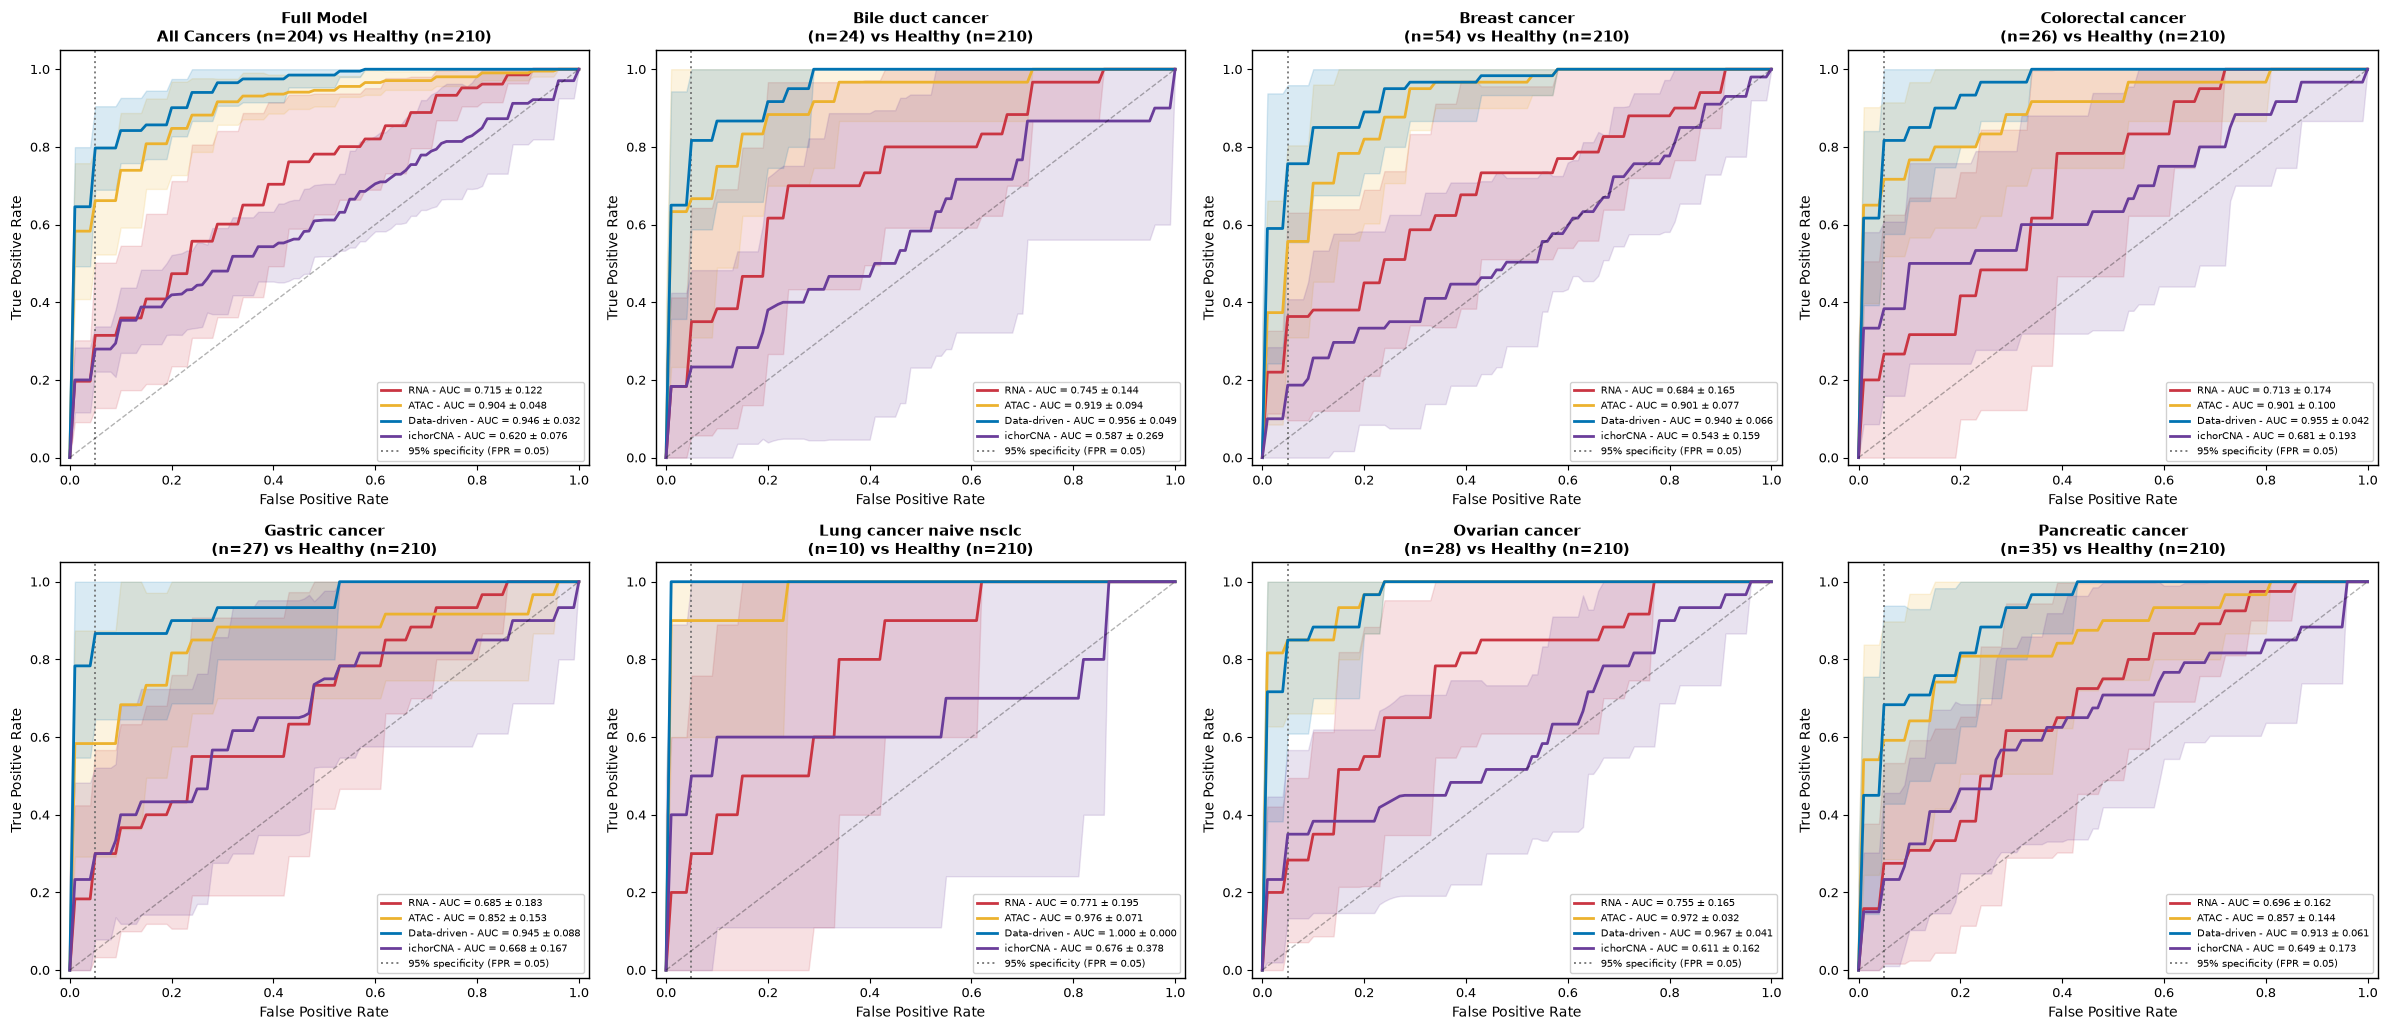

In [3]:
n_cancer_total = int((sample_disease != "Healthy").sum())
panels = [(None, f"Full Model\nAll Cancers (n={n_cancer_total}) vs Healthy (n={n_healthy})")]
panels += [(ct, f"{ct}\n(n={int(counts[ct])}) vs Healthy (n={n_healthy})")
           for ct in cancer_types]

ncols = 4
nrows = int(np.ceil(len(panels) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5.2 * nrows))
axes = np.atleast_2d(axes)
for idx, (ct, title) in enumerate(panels):
    draw_panel(axes[idx // ncols, idx % ncols], ct, title)
for idx in range(len(panels), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

plt.tight_layout()
os.makedirs("output", exist_ok=True)
fig.savefig("output/figS6.png", dpi=200, bbox_inches="tight")
fig.savefig("output/figS6.pdf", bbox_inches="tight")
plt.show()

## Check against the manuscript

Reference values from the submitted S6 panels (data-driven, per cancer type).

In [4]:
ref_dd = {"Bile duct cancer": 0.957, "Breast cancer": 0.943, "Colorectal cancer": 0.952,
          "Gastric cancer": 0.952, "Lung cancer": 1.000, "Ovarian cancer": 0.987,
          "Pancreatic cancer": 0.912}
print("Data-driven per-cancer AUC (computed vs manuscript S6 where legible):")
for ct in cancer_types:
    r = mean_roc_for("data_driven", ct)
    ms = ref_dd.get(ct)
    ms_str = f"(manuscript ~{ms:.3f})" if ms else ""
    print(f"  {ct:<22} {r['mean_auc']:.3f} ± {r['std_auc']:.3f}  over {r['n_folds']} folds  {ms_str}")

Data-driven per-cancer AUC (computed vs manuscript S6 where legible):
  Bile duct cancer       0.956 ± 0.049  over 10 folds  (manuscript ~0.957)
  Breast cancer          0.940 ± 0.066  over 10 folds  (manuscript ~0.943)
  Colorectal cancer      0.955 ± 0.042  over 10 folds  (manuscript ~0.952)
  Gastric cancer         0.945 ± 0.088  over 10 folds  (manuscript ~0.952)
  Lung cancer naive nsclc 1.000 ± 0.000  over 10 folds  
  Ovarian cancer         0.967 ± 0.041  over 10 folds  (manuscript ~0.987)
  Pancreatic cancer      0.913 ± 0.061  over 10 folds  (manuscript ~0.912)
